Spearman's Rank Correlation (Rain vs Price): 0.0377
Spearman's Rank Correlation (Temp vs Price): -0.1357


C:\Users\Ranuga\AppData\Local\Temp\ipykernel_27344\2508112290.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='location', y='price', ax=axes[0, 0], palette='viridis')
C:\Users\Ranuga\AppData\Local\Temp\ipykernel_27344\2508112290.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='vegetable_type', y='price', ax=axes[0, 1], palette='plasma')


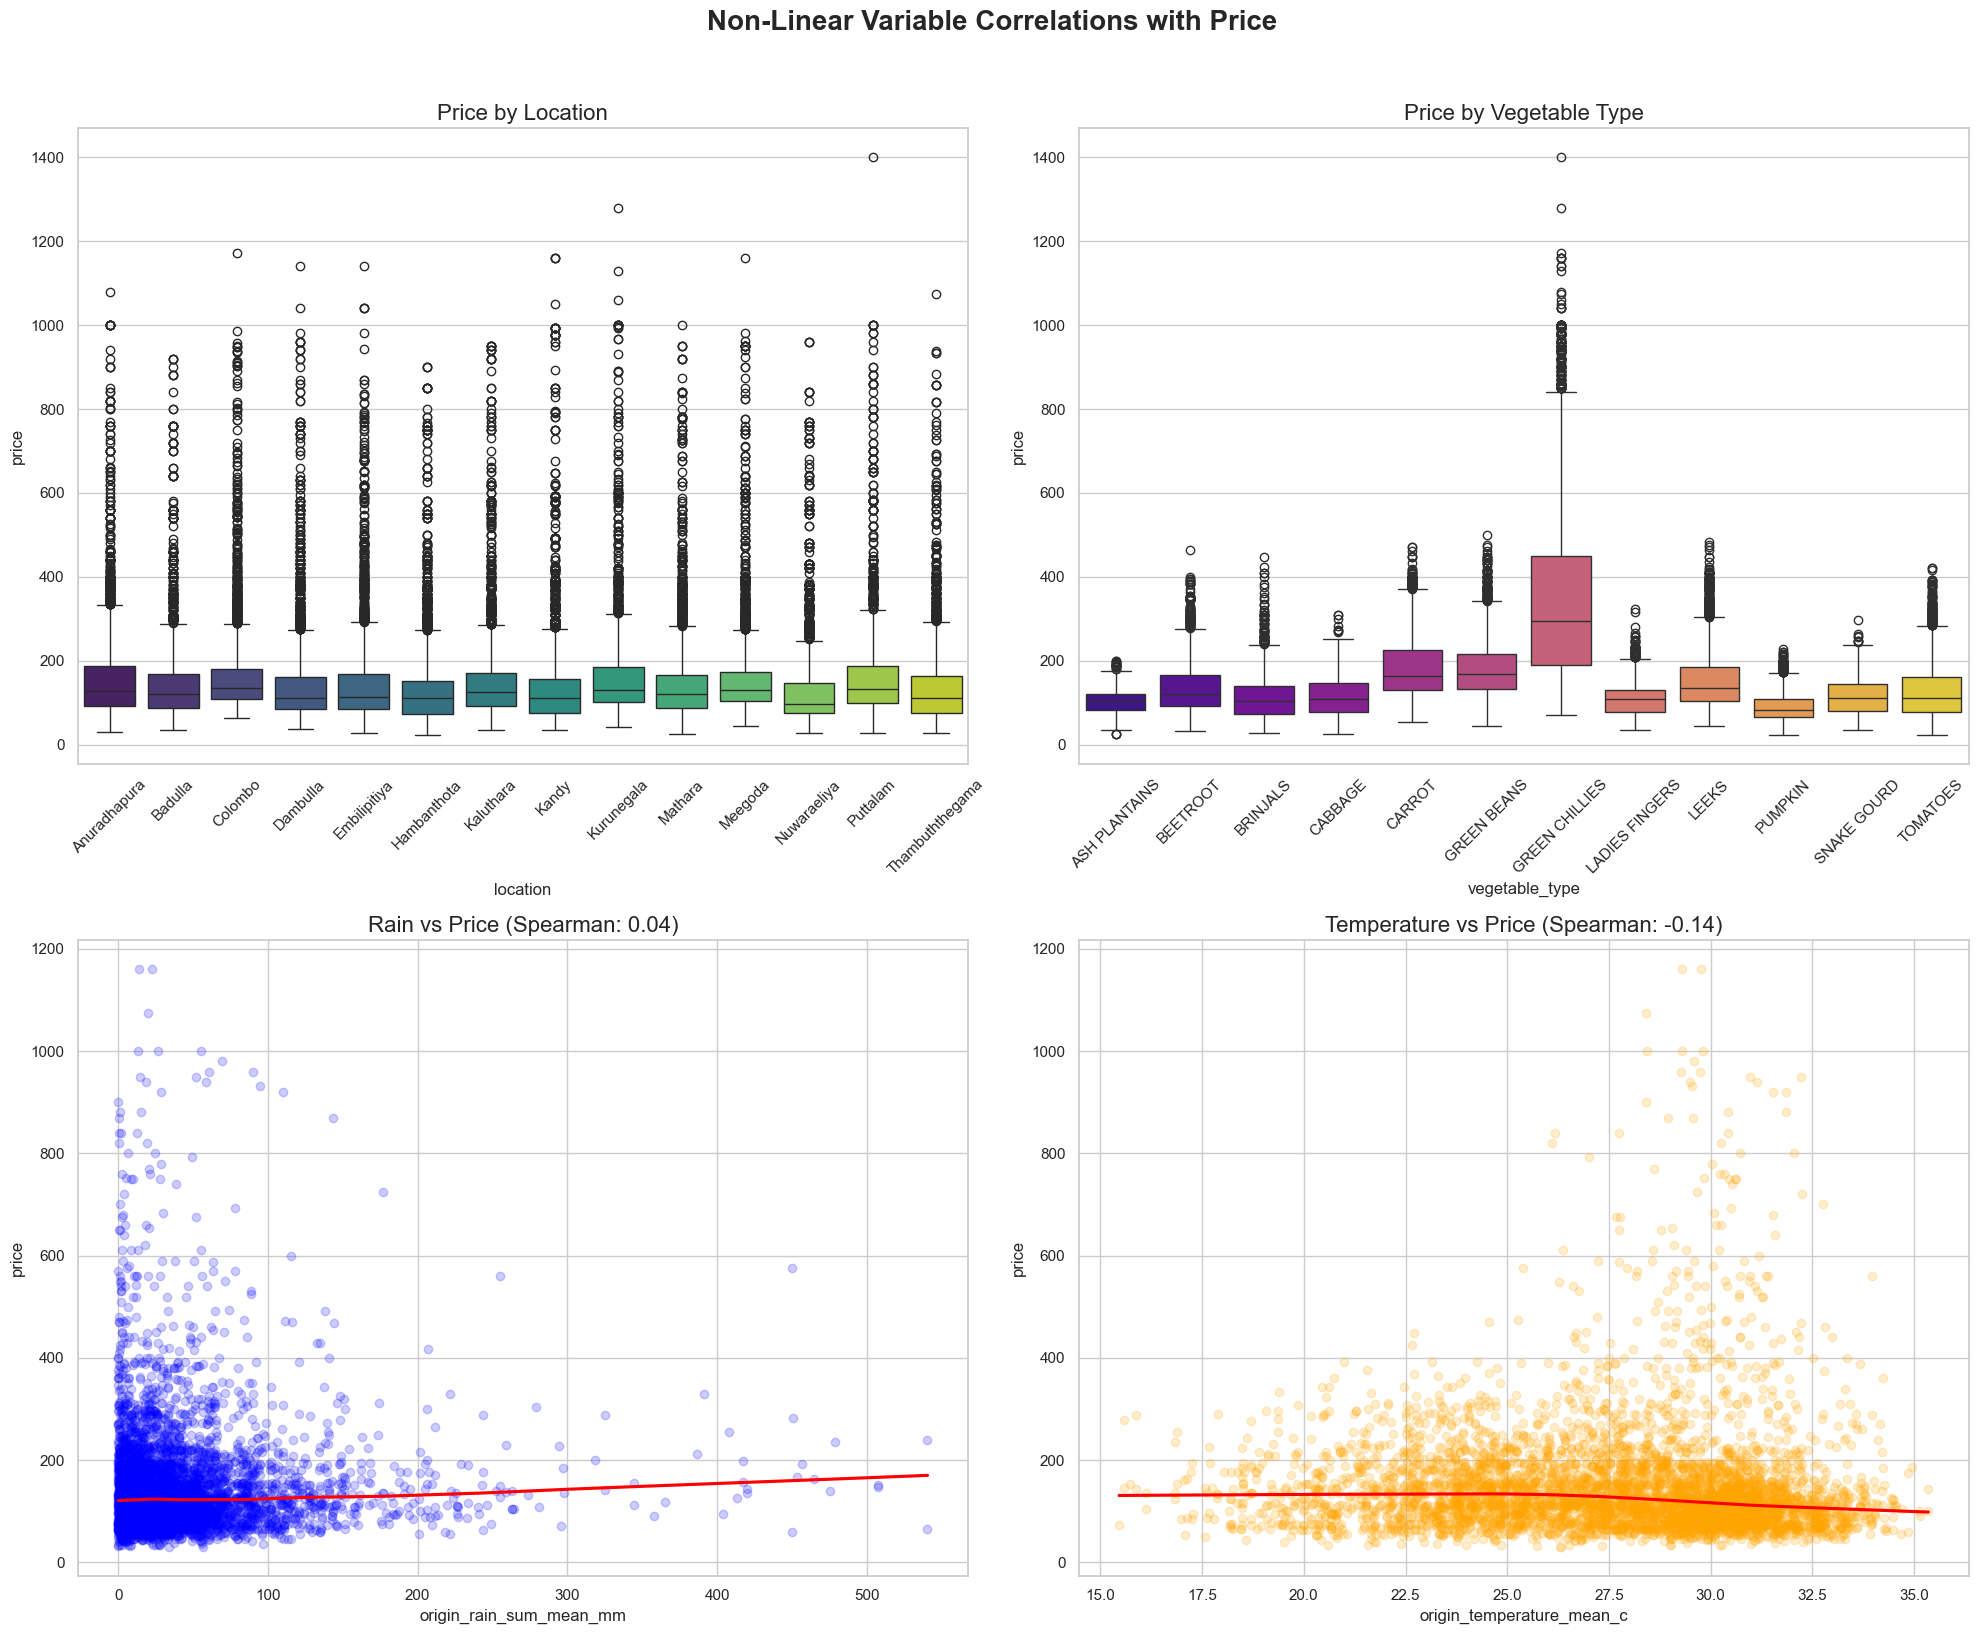

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from scipy.stats import spearmanr, pearsonr

# 1. Load the data
base_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.dirname(base_dir)
data_path = os.path.join(project_root, "Data Pre Processing", "Stage 3", "Final_Merged_Dataset.csv")

df = pd.read_csv(data_path)
df_clean = df.dropna(subset=['price', 'origin_rain_sum_mean_mm', 'origin_temperature_mean_c'])

# 2. Calculate Spearman's Rank Correlations
rain_corr, _ = spearmanr(df_clean['origin_rain_sum_mean_mm'], df_clean['price'])
temp_corr, _ = spearmanr(df_clean['origin_temperature_mean_c'], df_clean['price'])

print(f"Spearman's Rank Correlation (Rain vs Price): {rain_corr:.4f}")
print(f"Spearman's Rank Correlation (Temp vs Price): {temp_corr:.4f}")

# 3. Visualization
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Non-Linear Variable Correlations with Price', fontsize=20, fontweight='bold', y=1.02)

# --- Categorical Box Plots (Keep these as they are perfect) ---
sns.boxplot(data=df_clean, x='location', y='price', ax=axes[0, 0], palette='viridis')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_title('Price by Location', fontsize=16)

sns.boxplot(data=df_clean, x='vegetable_type', y='price', ax=axes[0, 1], palette='plasma')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_title('Price by Vegetable Type', fontsize=16)

# --- Weather vs Price with CURVED Trend Lines (LOWESS) ---
# We use a sample of 5,000 for speed as LOWESS is computationally heavy
df_sample = df_clean.sample(5000, random_state=42)

# Rain vs Price
sns.regplot(data=df_sample, x='origin_rain_sum_mean_mm', y='price', ax=axes[1, 0], 
            lowess=True, scatter_kws={'alpha':0.2, 'color': 'blue'}, line_kws={'color': 'red'})
axes[1, 0].set_title(f'Rain vs Price (Spearman: {rain_corr:.2f})', fontsize=16)

# Temp vs Price
sns.regplot(data=df_sample, x='origin_temperature_mean_c', y='price', ax=axes[1, 1], 
            lowess=True, scatter_kws={'alpha':0.2, 'color': 'orange'}, line_kws={'color': 'red'})
axes[1, 1].set_title(f'Temperature vs Price (Spearman: {temp_corr:.2f})', fontsize=16)

plt.tight_layout()
plt.show()


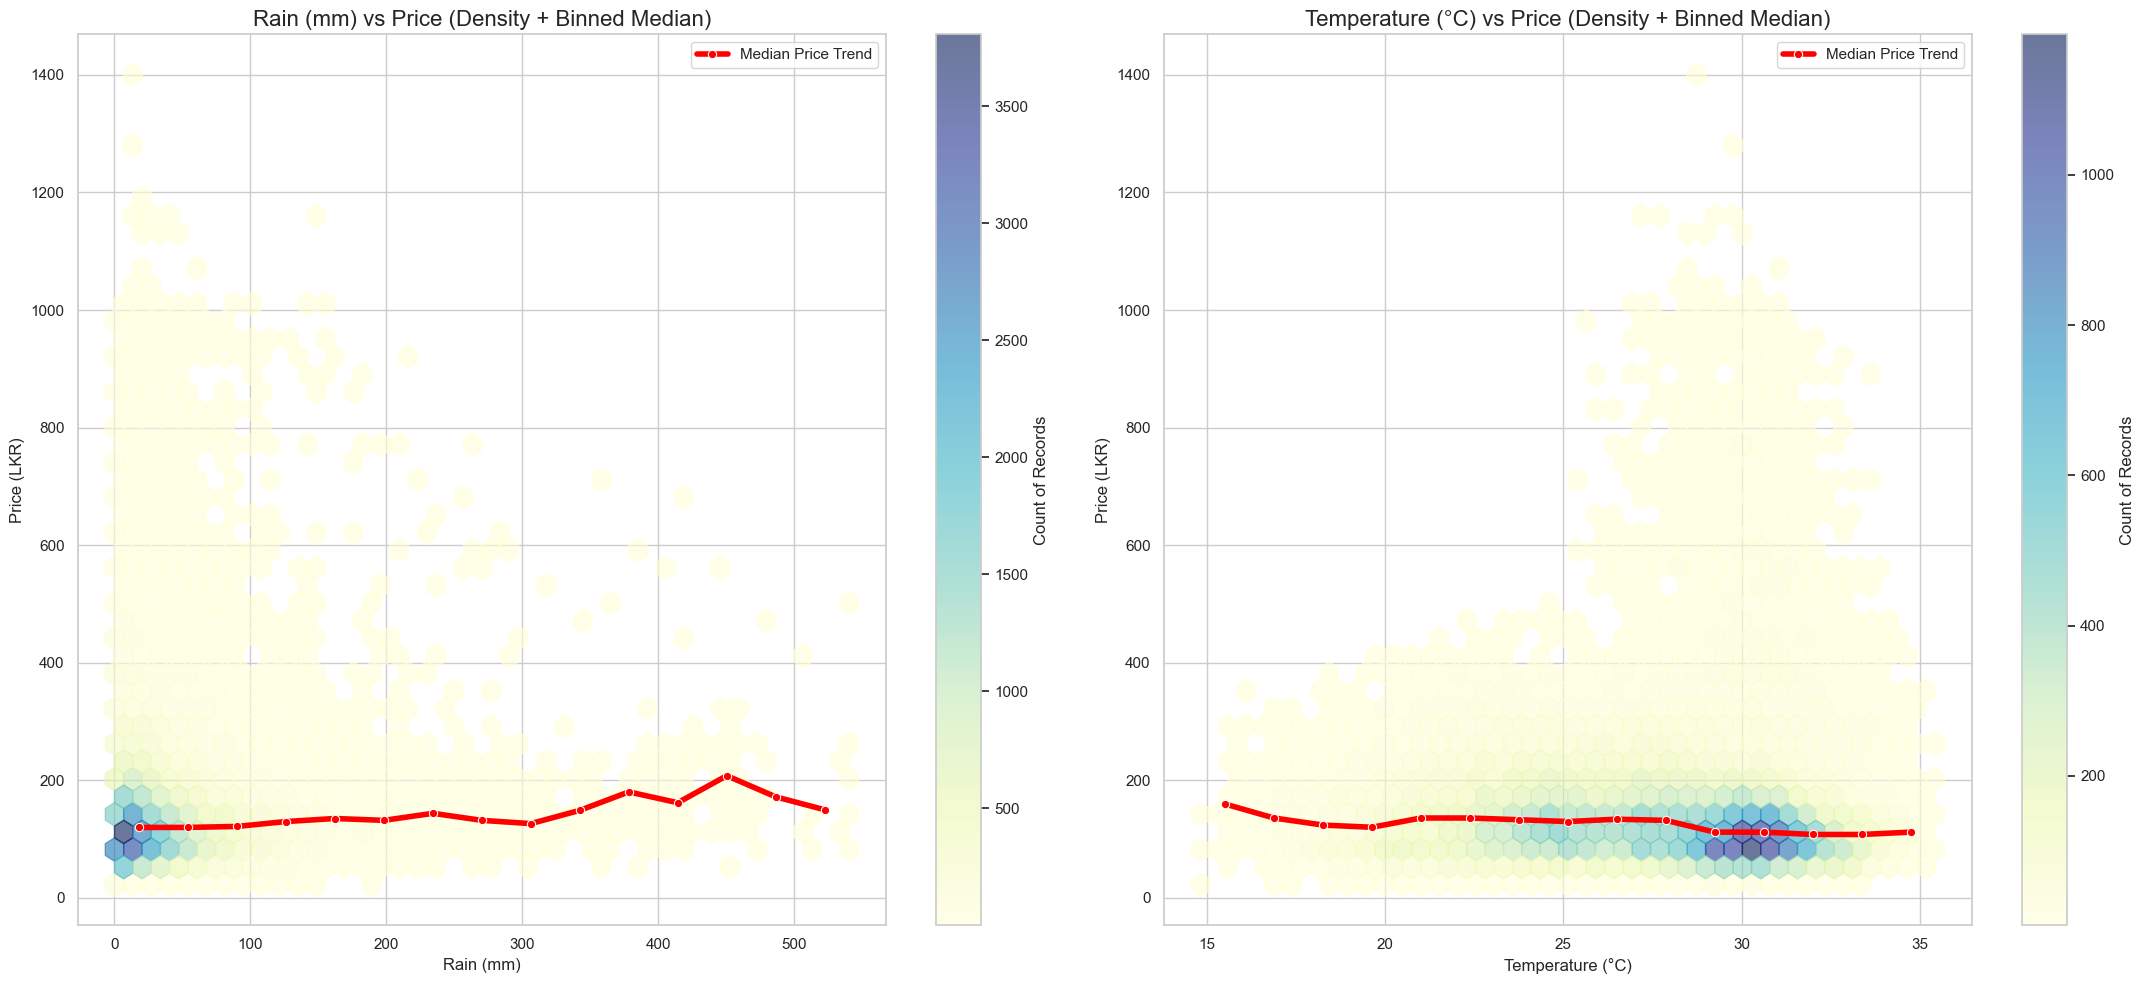

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming df_clean is already loaded
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

def plot_binned_trend(df, x_col, y_col, ax, label, color):
    # 1. Plot the Density (Hexbin)
    hb = ax.hexbin(df[x_col], df[y_col], gridsize=40, cmap='YlGnBu', mincnt=1, alpha=0.6)
    fig.colorbar(hb, ax=ax, label='Count of Records')
    
    # 2. Plot the Binned Median Line
    # Create 15 equal bins based on X-axis range
    df['bins'] = pd.cut(df[x_col], bins=15)
    # Calculate median price per bin
    binned_data = df.groupby('bins', observed=True)[y_col].median().reset_index()
    # Get the center point of each bin for plotting
    binned_data['bin_center'] = binned_data['bins'].apply(lambda x: x.mid)
    
    # Draw the robust median line
    sns.lineplot(data=binned_data, x='bin_center', y=y_col, ax=ax, 
                 color='red', linewidth=4, marker='o', label='Median Price Trend')
    
    ax.set_title(f'{label} vs Price (Density + Binned Median)', fontsize=16)
    ax.set_xlabel(label)
    ax.set_ylabel('Price (LKR)')
    ax.legend()

# Run the mechanisms
plot_binned_trend(df_clean, 'origin_rain_sum_mean_mm', 'price', axes[0], 'Rain (mm)', 'blue')
plot_binned_trend(df_clean, 'origin_temperature_mean_c', 'price', axes[1], 'Temperature (°C)', 'orange')

plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
from scipy.stats import spearmanr

# 1. Calculate Overall Spearman Correlation
# (Using df_clean from your previous cells)
overall_rain_corr, _ = spearmanr(df_clean['origin_rain_sum_mean_mm'], df_clean['price'])
overall_temp_corr, _ = spearmanr(df_clean['origin_temperature_mean_c'], df_clean['price'])

print("--- OVERALL SPEARMAN CORRELATIONS ---")
print(f"Origin Rain vs Price:        {overall_rain_corr:.4f}")
print(f"Origin Temperature vs Price: {overall_temp_corr:.4f}")
print("-" * 40)

# 2. Advanced Insight: Spearman Correlation PER VEGETABLE
# This reveals which specific vegetables are most "Weather Sensitive"
veg_correlations = []

for veg in df_clean['vegetable_type'].unique():
    subset = df_clean[df_clean['vegetable_type'] == veg]
    
    # Calculate Rain Correlation for this veg
    r_corr, _ = spearmanr(subset['origin_rain_sum_mean_mm'], subset['price'])
    # Calculate Temp Correlation for this veg
    t_corr, _ = spearmanr(subset['origin_temperature_mean_c'], subset['price'])
    
    veg_correlations.append({
        'Vegetable': veg,
        'Rain_Correlation': r_corr,
        'Temp_Correlation': t_corr
    })

# Display as a nicely formatted Table
corr_df = pd.DataFrame(veg_correlations).sort_values(by='Rain_Correlation', ascending=False)
print("\n--- SPEARMAN CORRELATION BY VEGETABLE TYPE ---")
print(corr_df.to_string(index=False))


--- OVERALL SPEARMAN CORRELATIONS ---
Origin Rain vs Price:        0.0377
Origin Temperature vs Price: -0.1357
----------------------------------------

--- SPEARMAN CORRELATION BY VEGETABLE TYPE ---
     Vegetable  Rain_Correlation  Temp_Correlation
   SNAKE GOURD          0.112433          0.012595
      TOMATOES          0.096738         -0.005365
      BRINJALS          0.082638         -0.066502
 ASH PLANTAINS          0.081922         -0.070742
         LEEKS          0.058825          0.046646
LADIES FINGERS          0.048159         -0.076829
       PUMPKIN          0.029906          0.049876
   GREEN BEANS          0.016544          0.072382
        CARROT          0.011619          0.108356
       CABBAGE          0.000728          0.113511
GREEN CHILLIES         -0.026126         -0.098323
      BEETROOT         -0.061964          0.050850


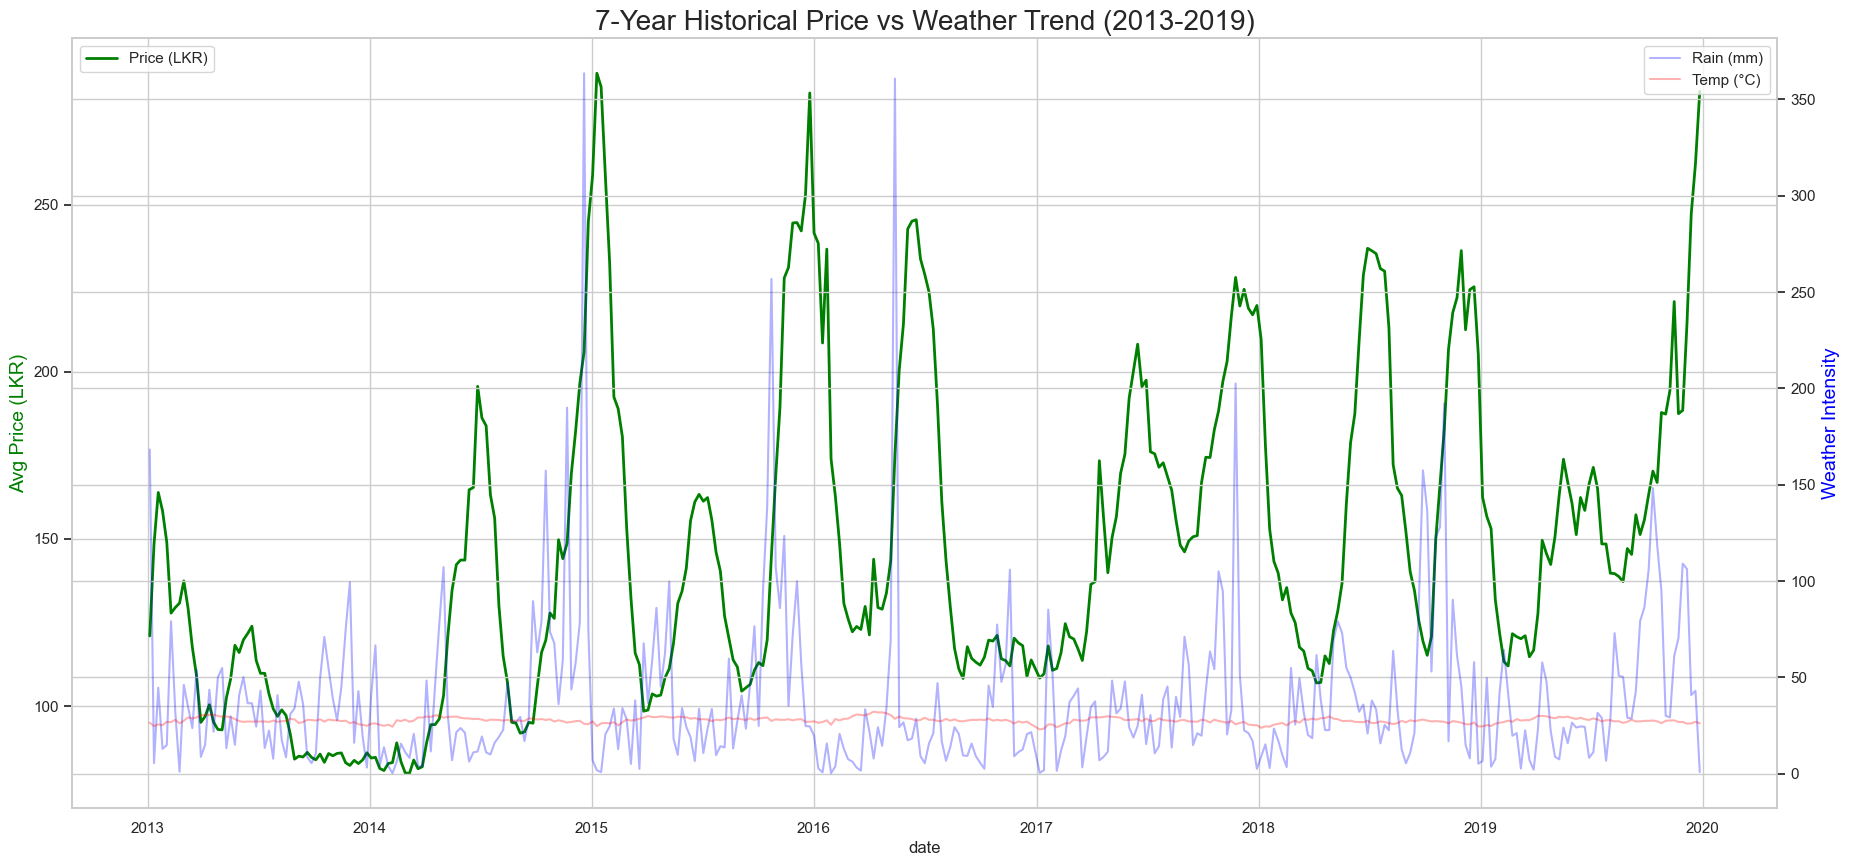

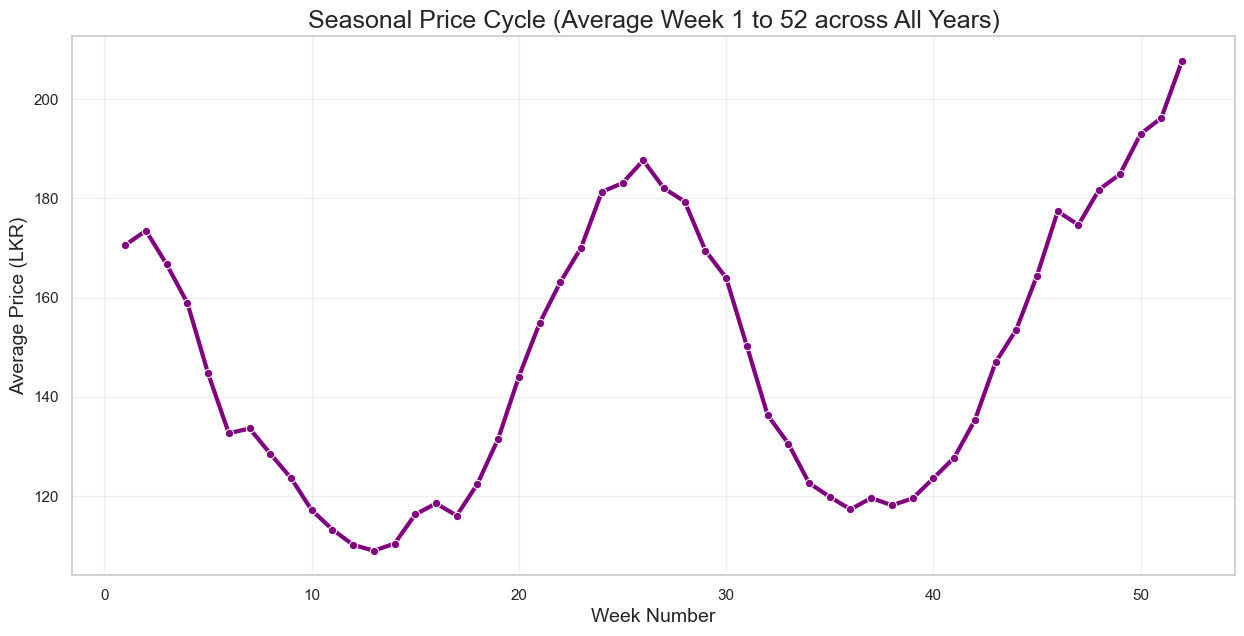

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# 1. Create the Time Axis Function
def get_week_date(year, week_str):
    # Convert 'w1' to 1 by removing 'w'
    if isinstance(week_str, str):
        week_num = int(week_str.replace('w', '').replace('W', ''))
    else:
        week_num = int(week_str)
        
    # Find the first day of the year
    first_day = datetime(year, 1, 1)
    # Target the first Friday of that year
    days_to_friday = (4 - first_day.weekday() + 7) % 7
    first_friday = first_day + timedelta(days=days_to_friday)
    # Add weeks
    return first_friday + timedelta(weeks=week_num-1)

# Apply the conversion (now handles 'w1', 'w2' correctly)
df_clean['date'] = df_clean.apply(lambda x: get_week_date(int(x['year']), x['week']), axis=1)

# 2. Continuous Time Series Plot
# (Rest of the code is the same)
ts_data = df_clean.groupby('date')[['price', 'origin_rain_sum_mean_mm', 'origin_temperature_mean_c']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(22, 10))
ax2 = ax1.twinx()

sns.lineplot(data=ts_data, x='date', y='price', ax=ax1, color='green', linewidth=2, label='Price (LKR)')
sns.lineplot(data=ts_data, x='date', y='origin_rain_sum_mean_mm', ax=ax2, color='blue', alpha=0.3, label='Rain (mm)')
sns.lineplot(data=ts_data, x='date', y='origin_temperature_mean_c', ax=ax2, color='red', alpha=0.3, label='Temp (°C)')

ax1.set_title('7-Year Historical Price vs Weather Trend (2013-2019)', fontsize=20)
ax1.set_ylabel('Avg Price (LKR)', fontsize=14, color='green')
ax2.set_ylabel('Weather Intensity', fontsize=14, color='blue')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

# 3. Seasonal "Average Year" Plot
# Prepare numeric week for the seasonal plot
df_clean['week_num'] = df_clean['week'].apply(lambda x: int(str(x).replace('w', '').replace('W', '')))
seasonal_data = df_clean.groupby('week_num')[['price', 'origin_rain_sum_mean_mm']].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(data=seasonal_data, x='week_num', y='price', marker='o', color='purple', linewidth=3)
plt.title('Seasonal Price Cycle (Average Week 1 to 52 across All Years)', fontsize=18)
plt.xlabel('Week Number', fontsize=14)
plt.ylabel('Average Price (LKR)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()


C:\Users\Ranuga\AppData\Local\Temp\ipykernel_27344\1339268668.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lag_df, x='Lag (Weeks)', y='Rain_Correlation', ax=ax1, palette='Blues_d')
C:\Users\Ranuga\AppData\Local\Temp\ipykernel_27344\1339268668.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lag_df, x='Lag (Weeks)', y='Temp_Correlation', ax=ax2, palette='Oranges_d')


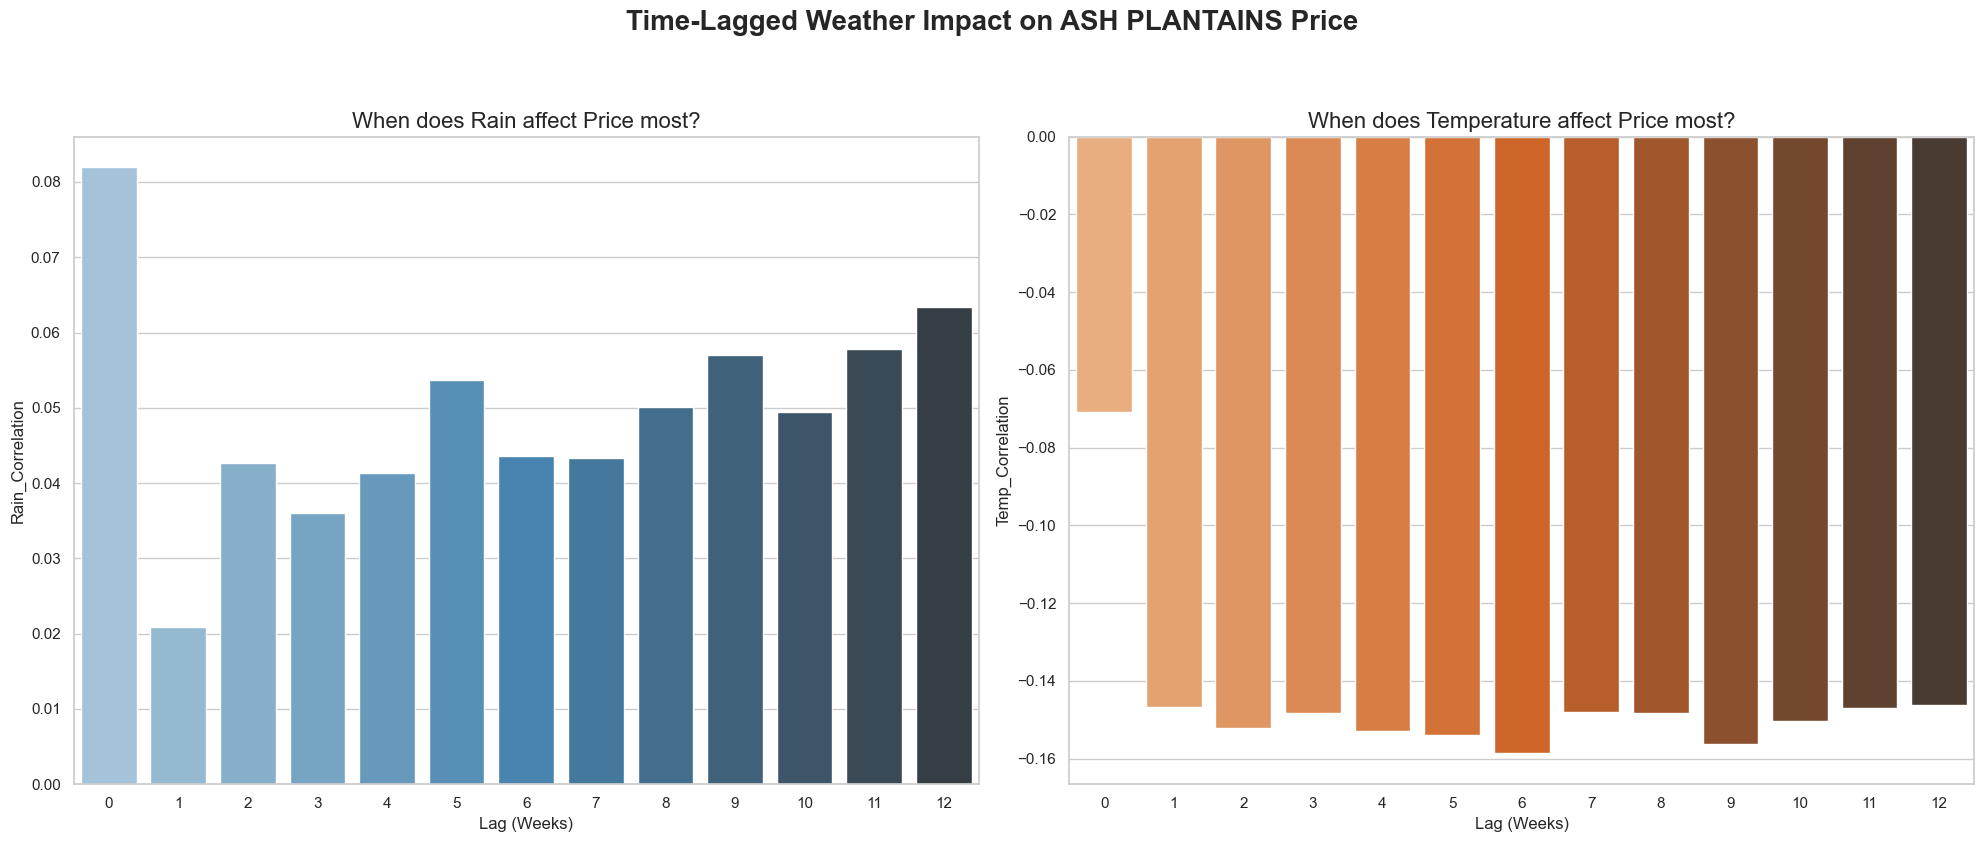

PEAK RAIN IMPACT: Weather from 0 weeks ago has the strongest effect.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime, timedelta
from scipy.stats import spearmanr

# --- 1. SETUP & DATA LOADING ---
base_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.dirname(base_dir)
data_path = os.path.join(project_root, "Data Pre Processing", "Stage 3", "Final_Merged_Dataset.csv")

df = pd.read_csv(data_path)

# Data Cleaning
df_clean = df.dropna(subset=['price', 'origin_rain_sum_mean_mm', 'origin_temperature_mean_c'])

# Time Conversion Logic (Handles 'w1', 'w2' etc.)
def get_week_date(year, week_str):
    week_num = int(str(week_str).replace('w', '').replace('W', ''))
    first_day = datetime(year, 1, 1)
    days_to_friday = (4 - first_day.weekday() + 7) % 7
    first_friday = first_day + timedelta(days=days_to_friday)
    return first_friday + timedelta(weeks=week_num-1)

df_clean['date'] = df_clean.apply(lambda x: get_week_date(int(x['year']), x['week']), axis=1)


# --- 2. LAGGED CORRELATION ANALYSIS ---
# Select a vegetable and sort by date
target_veg = df_clean['vegetable_type'].unique()[0] 
subset = df_clean[df_clean['vegetable_type'] == target_veg].copy().sort_values('date')

lags = range(0, 13) 
lag_results = []

for lag in lags:
    # Shift weather data forward
    lagged_rain = subset['origin_rain_sum_mean_mm'].shift(lag)
    lagged_temp = subset['origin_temperature_mean_c'].shift(lag)
    
    # Calculate correlation
    valid_idx = lagged_rain.notna()
    r_corr, _ = spearmanr(subset.loc[valid_idx, 'price'], lagged_rain[valid_idx])
    t_corr, _ = spearmanr(subset.loc[valid_idx, 'price'], lagged_temp[valid_idx])
    
    lag_results.append({'Lag (Weeks)': lag, 'Rain_Correlation': r_corr, 'Temp_Correlation': t_corr})

lag_df = pd.DataFrame(lag_results)

# --- 3. VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(f'Time-Lagged Weather Impact on {target_veg} Price', fontsize=20, fontweight='bold', y=1.05)

sns.barplot(data=lag_df, x='Lag (Weeks)', y='Rain_Correlation', ax=ax1, palette='Blues_d')
ax1.set_title('When does Rain affect Price most?', fontsize=16)

sns.barplot(data=lag_df, x='Lag (Weeks)', y='Temp_Correlation', ax=ax2, palette='Oranges_d')
ax2.set_title('When does Temperature affect Price most?', fontsize=16)

plt.tight_layout()
plt.show()

print(f"PEAK RAIN IMPACT: Weather from {int(lag_df.loc[lag_df['Rain_Correlation'].abs().idxmax()]['Lag (Weeks)'])} weeks ago has the strongest effect.")


Processing Lag Analysis for: ASH PLANTAINS...


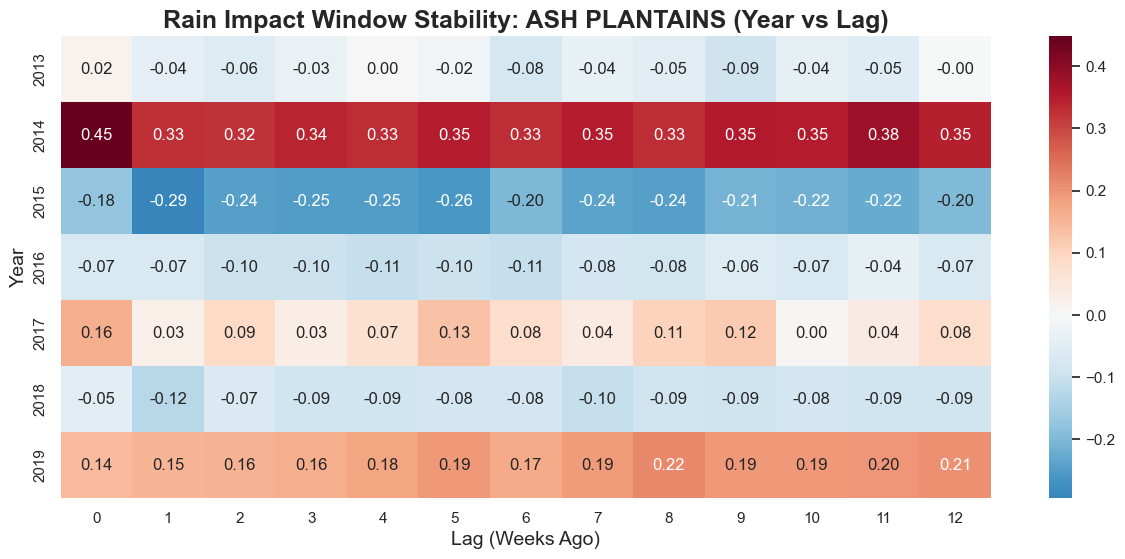

----------------------------------------------------------------------------------------------------
Processing Lag Analysis for: BEETROOT...


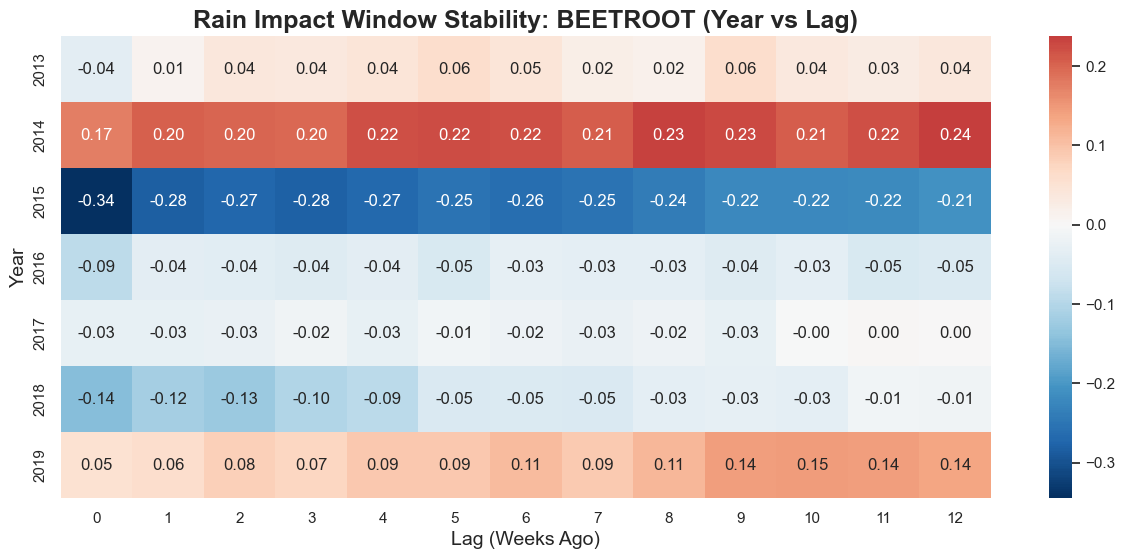

----------------------------------------------------------------------------------------------------
Processing Lag Analysis for: BRINJALS...


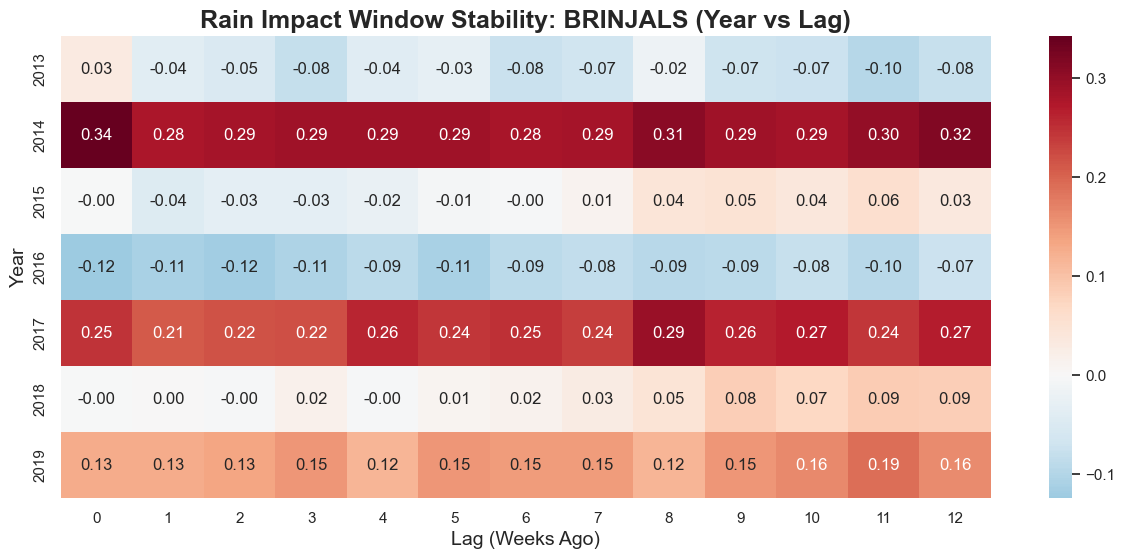

----------------------------------------------------------------------------------------------------
Processing Lag Analysis for: CABBAGE...


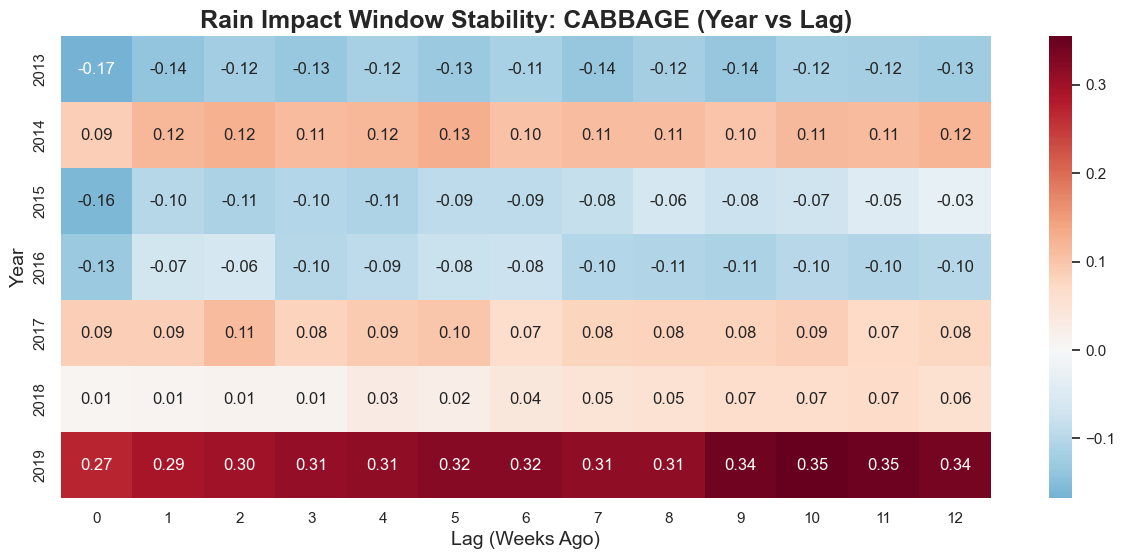

----------------------------------------------------------------------------------------------------
Processing Lag Analysis for: CARROT...


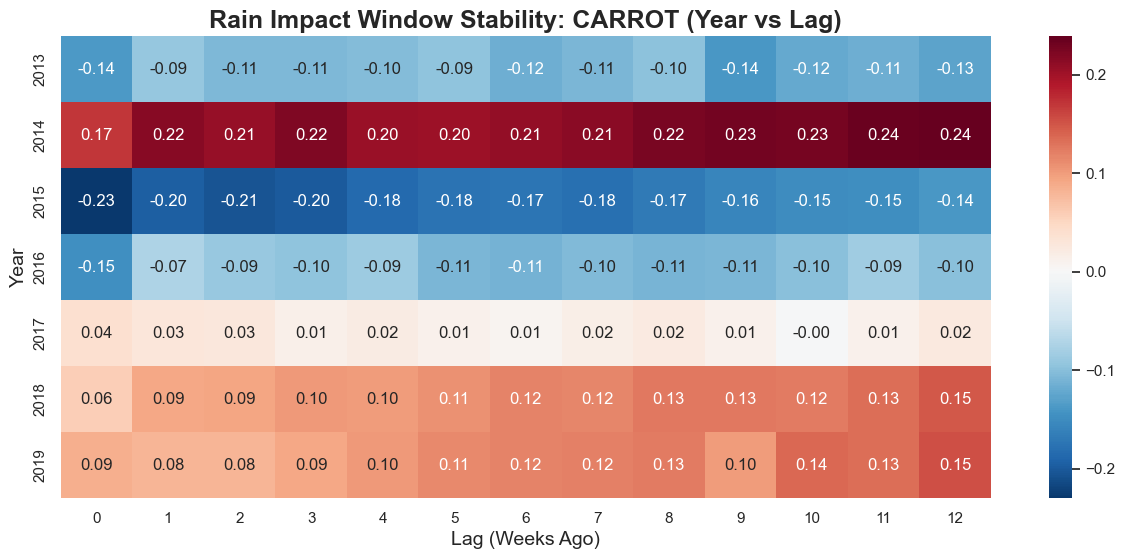

----------------------------------------------------------------------------------------------------
Processing Lag Analysis for: GREEN BEANS...


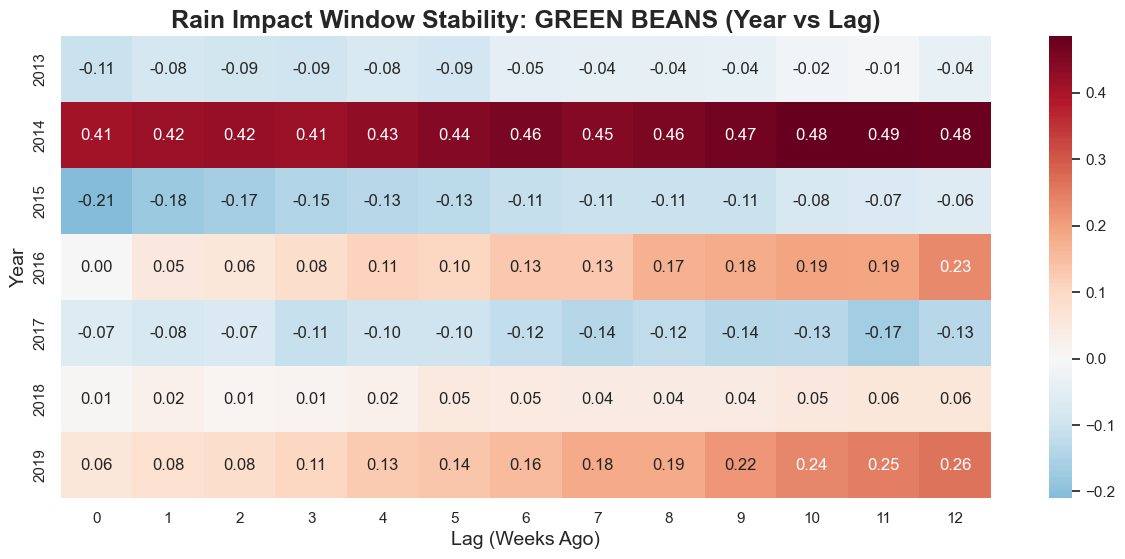

----------------------------------------------------------------------------------------------------
Processing Lag Analysis for: GREEN CHILLIES...


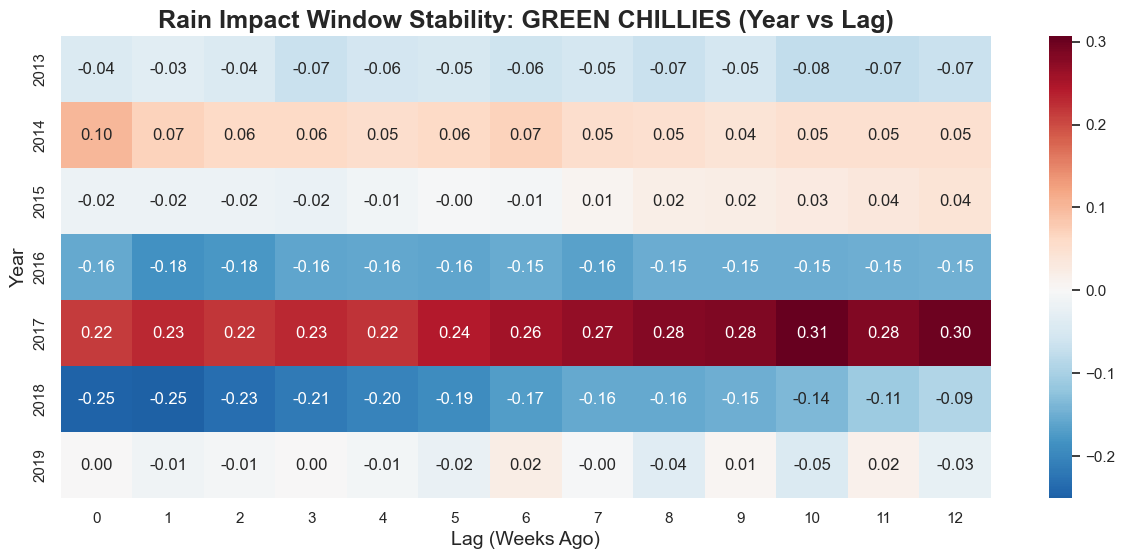

----------------------------------------------------------------------------------------------------
Processing Lag Analysis for: LADIES FINGERS...


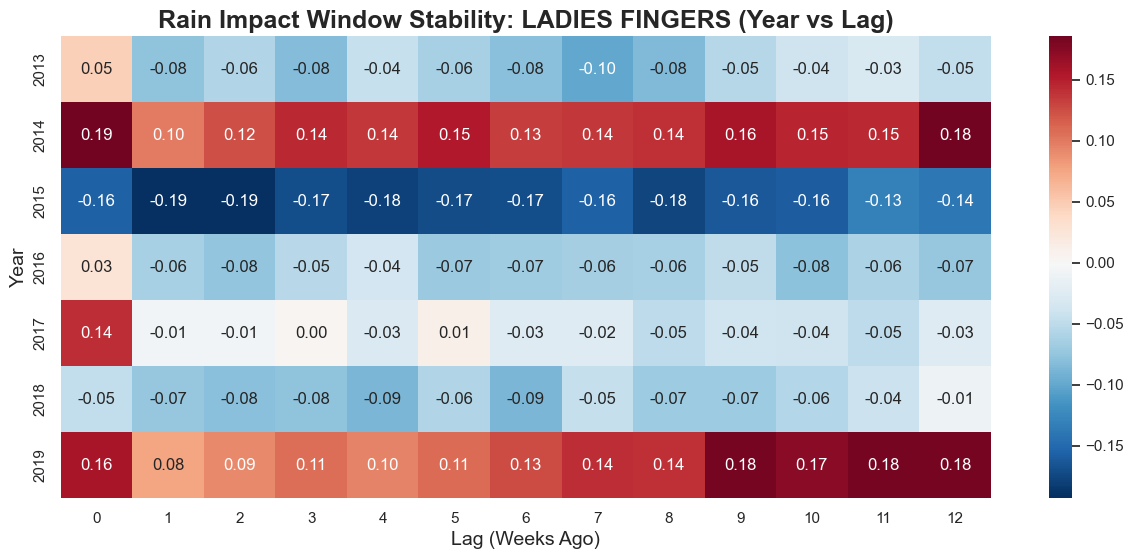

----------------------------------------------------------------------------------------------------
Processing Lag Analysis for: LEEKS...


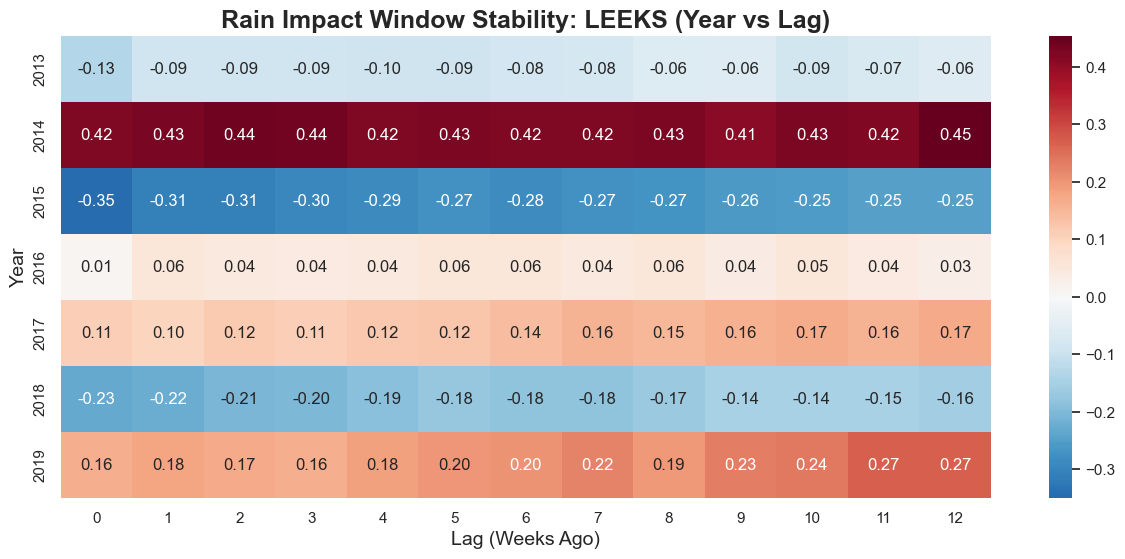

----------------------------------------------------------------------------------------------------
Processing Lag Analysis for: PUMPKIN...


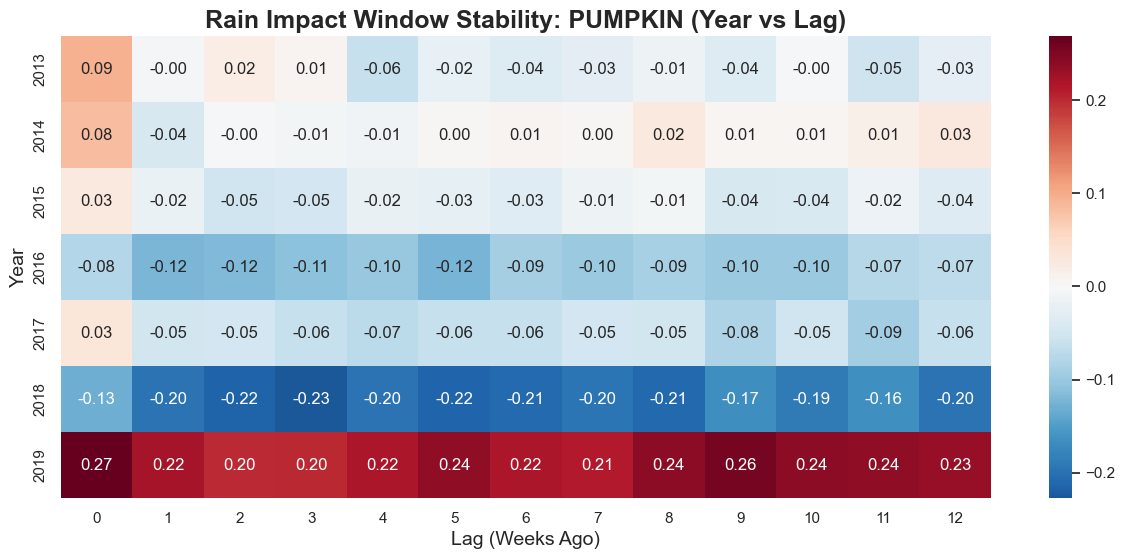

----------------------------------------------------------------------------------------------------
Processing Lag Analysis for: SNAKE GOURD...


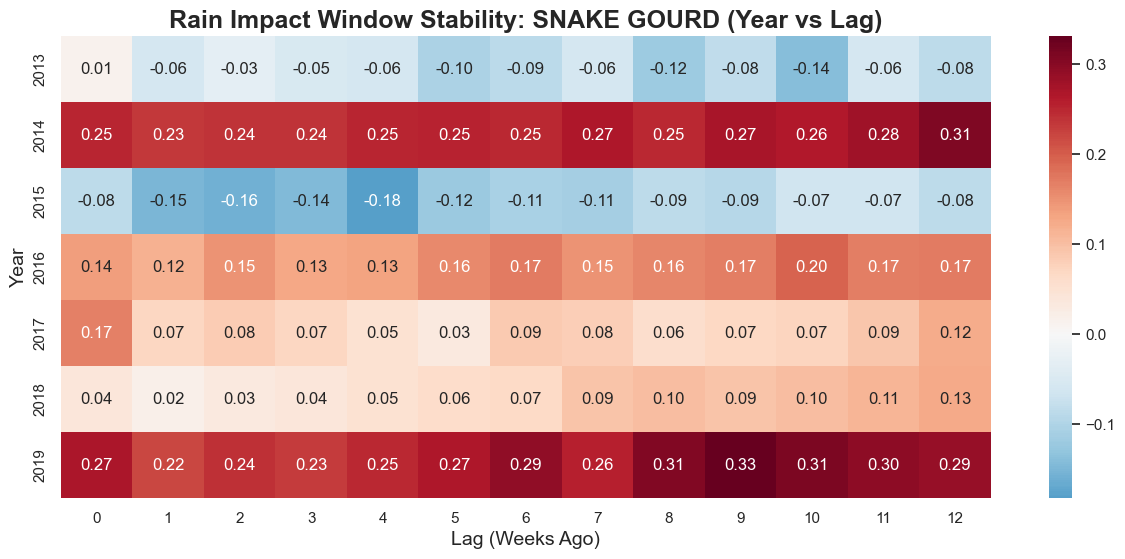

----------------------------------------------------------------------------------------------------
Processing Lag Analysis for: TOMATOES...


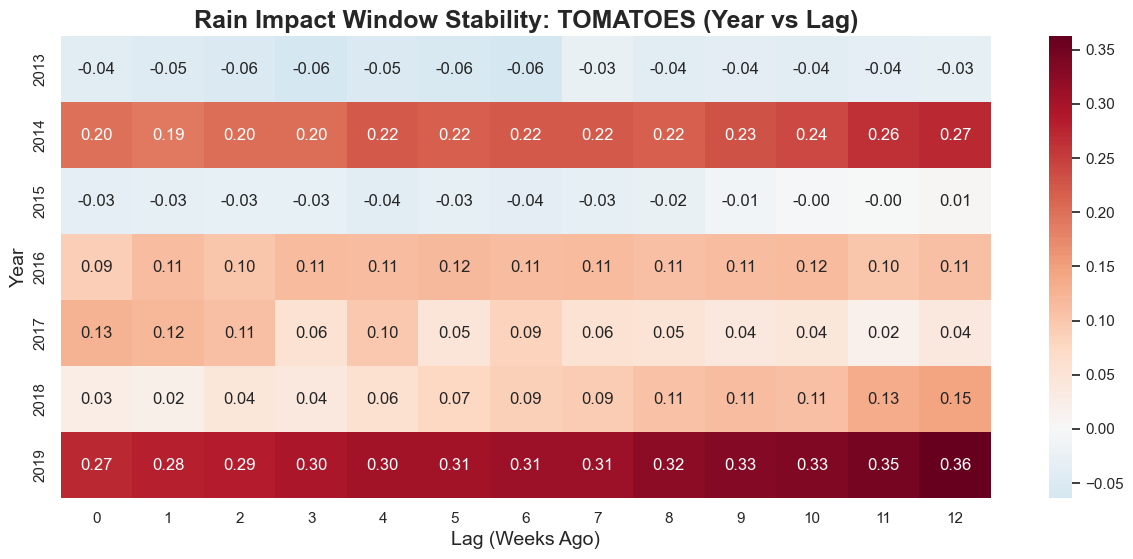

----------------------------------------------------------------------------------------------------


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# 1. Get list of all vegetables
vegetables = df_clean['vegetable_type'].unique()
years = sorted(df_clean['year'].unique())
lags = range(0, 13)

# 2. Iterate through each vegetable to create a "Stability Heatmap"
for veg in vegetables:
    print(f"Processing Lag Analysis for: {veg}...")
    veg_subset = df_clean[df_clean['vegetable_type'] == veg].copy().sort_values('date')
    
    # Storage for this vegetable's annual results
    annual_rain_lags = []
    
    for yr in years:
        year_subset = veg_subset[veg_subset['year'] == yr].copy()
        
        # Check if we have enough data for this year (need at least some weeks)
        if len(year_subset) < 20: continue 
            
        lags_for_year = {}
        for lag in lags:
            # Shift weather data
            lagged_rain = year_subset['origin_rain_sum_mean_mm'].shift(lag)
            valid_idx = lagged_rain.notna()
            
            if valid_idx.sum() > 5:
                corr, _ = spearmanr(year_subset.loc[valid_idx, 'price'], lagged_rain[valid_idx])
                lags_for_year[lag] = corr
            else:
                lags_for_year[lag] = 0
        
        lags_for_year['year'] = yr
        annual_rain_lags.append(lags_for_year)

    # Convert to DataFrame for Heatmap
    heatmap_df = pd.DataFrame(annual_rain_lags).set_index('year')

    # 3. Plotting the Heatmap
    plt.figure(figsize=(15, 6))
    sns.heatmap(heatmap_df, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
    plt.title(f'Rain Impact Window Stability: {veg} (Year vs Lag)', fontsize=18, fontweight='bold')
    plt.xlabel('Lag (Weeks Ago)', fontsize=14)
    plt.ylabel('Year', fontsize=14)
    plt.show()
    
    print("-" * 100)
